# Computational Finance Group 7 Assessment Notebook

---
## 1. Setup

### Libraries & Dependencies

Loading all necessary libraries and `module.py`.

In [1]:
import importlib, sys, subprocess

required_packages = ['numpy', 'pandas', 'matplotlib', 'yahooquery', 'yfinance']

missing = [pkg for pkg in required_packages if importlib.util.find_spec(pkg) is None]
if missing:
    print(f'Installing missing packages: {", ".join(missing)} ...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', *missing])
    print('Installation complete.')
else:
    print('All dependencies satisfied.')

try:
    import module
    print('module.py loaded successfully.')
except ModuleNotFoundError:
    raise ImportError(
        'module.py was not found. Place it in the same directory as this notebook.'
    )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline

importlib.reload(module);

All dependencies satisfied.
module.py loaded successfully.


### Load Price Data

We load adjusted close prices for XLF, XLB, XLK, and the S&P 500 from local cache. 

In [2]:
import os, pathlib

try:
    import yfinance as yf
    yfinance_ok = True
except ImportError:
    yfinance_ok = False

# Three sector ETF baskets - one signal per basket
FINANCE_TICKERS    = ['XLF']   # Signal 0: MA Crossover - Financials
MATERIALS_TICKERS  = ['XLB']   # Signal 1: RSI          - Materials
TECHNOLOGY_TICKERS = ['XLK']   # Signal 2: Donchian     - Technology

ALL_TRADED = FINANCE_TICKERS + MATERIALS_TICKERS + TECHNOLOGY_TICKERS
tickers    = ALL_TRADED + ['^GSPC']

data_dir = pathlib.Path('data')
data_dir.mkdir(exist_ok=True)

def load_csv(csv_name, cols):
    path = data_dir / csv_name
    if path.exists():
        df = pd.read_csv(path, index_col=0, parse_dates=True)
        return df[[c for c in cols if c in df.columns]]
    return pd.DataFrame()

# XLB and XLK are sourced from the full sector ETF cache (2000-2025)
fin  = load_csv('xlf.csv',             FINANCE_TICKERS)
mats = load_csv('sector_etfs_ext.csv', MATERIALS_TICKERS)
tech = load_csv('sector_etfs_ext.csv', TECHNOLOGY_TICKERS)
spx  = load_csv('spx.csv',             ['^GSPC'])

missing = []
for col, src in [(FINANCE_TICKERS, fin), (MATERIALS_TICKERS, mats),
                 (TECHNOLOGY_TICKERS, tech), (['^GSPC'], spx)]:
    for c in col:
        if c not in (src.columns if not src.empty else []):
            missing.append(c)

#If a ticker is missing, yfinance is used as a fallback.
if missing and yfinance_ok:                                 
    print(f'Downloading missing tickers via yfinance: {missing}')
    raw = yf.download(missing, start='2010-01-01', end='2025-12-31',
                      progress=False, auto_adjust=True)
    dl = raw['Close'] if isinstance(raw.columns, pd.MultiIndex) else raw
    dl.index = pd.to_datetime(dl.index)
    for c in missing:
        if c in dl.columns:
            if c in FINANCE_TICKERS:    fin[c]  = dl[c]
            elif c in MATERIALS_TICKERS: mats[c] = dl[c]
            elif c in TECHNOLOGY_TICKERS: tech[c] = dl[c]
            else:                        spx[c]  = dl[c]

df_prices = fin.join(mats, how='outer').join(tech, how='outer').join(spx, how='outer')
df_prices = df_prices.ffill().dropna()
df_prices.index = pd.to_datetime(df_prices.index)

print(f'df_prices: {df_prices.shape}  ({df_prices.index[0].date()} to {df_prices.index[-1].date()})')
print(f'Columns  : {list(df_prices.columns)}')

df_prices: (4023, 4)  (2010-01-04 to 2025-12-30)
Columns  : ['XLF', 'XLB', 'XLK', '^GSPC']


---
## 2. Signals

## Signal 0 – Moving Average Crossover (Financials ETF: XLF)

We use XLF because interest rate cycles create slow, persistent trends in financials - exactly what a long-window MA crossover captures.

$$s_t = 1 \iff \text{MA}_{w_s}(t) > \text{MA}_{w_l}(t), \qquad s_t = 0 \text{ otherwise}$$

IS-optimal parameters (research notebook 4.): $w_s = 20$, $w_l = 100$.

**Reference:** Brock, W., Lakonishok, J., & LeBaron, B. (1992). *Simple Technical Trading Rules and the Stochastic Properties of Stock Returns.* JF, 47(5), 1731–1764.

## Signal 1 – RSI Mean Reversion (Materials ETF: XLB)

We use XLB because commodity cycles push Materials into recurring overbought/oversold extremes that revert once the PMI cycle turns. XLB ranked first in our 3. screening by Min OOS Sortino for RSI.

$$\text{RSI}_{14}(t) = 100 - \frac{100}{1 + \frac{\text{Avg Gain}_{14}}{\text{Avg Loss}_{14}}}$$

**Entry:** $\text{RSI}_{14}(t) < \text{oversold}$ - IS-optimal: $\text{oversold} = 45$
&emsp;
**Exit:** $\text{RSI}_{14}(t) > \text{overbought}$ - IS-optimal: $\text{overbought} = 65$

**Reference:** Wilder, J. W. (1978). *New Concepts in Technical Trading Systems.*

## Signal 2 – Donchian Channel Breakout (Technology ETF: XLK)

We use XLK because technology returns follow multi-year adoption S-curves that produce sustained directional breakouts. The asymmetric two-window form ($M < N$) uses a longer entry window for breakout confirmation and a shorter exit for more responsive position management.

$$s_t = 1 \iff P_t > \max_{i \in [t-N,\,t-1]} P_i \quad \text{(entry: new N-day high)}$$
$$s_t = 0 \iff P_t < \min_{i \in [t-M,\,t-1]} P_i \quad \text{(exit: new M-day low)}$$

IS-optimal parameters: $N = 125$ days (entry), $M = 100$ days (exit).

**Reference:** Donchian, R. D. (1960). *High Finance in Copper.*

### IS-Optimal Parameters

Parameters are taken directly from the research notebook (4. grid search on 2010–2019 data). No re-optimisation is performed here - parameters are frozen before any out-of-sample evaluation.

In [11]:
# Parameters from research notebook 4. grid search (2010-2019 in-sample only)
is_mask = df_prices.index <= '2019-12-31'

best_ma       = {'short_window': 20, 'long_window': 100}
best_rsi      = {'oversold': 45, 'overbought': 65}
best_donchian = {'entry_window': 125, 'exit_window': 100}

def signal_0(series):
    return module.ma_signal(series, **best_ma)

def signal_1(series):
    return module.rsi_signal(series, period=14, **best_rsi)

def signal_2(series):
    return module.donchian_signal(series, **best_donchian)

print('IS-optimal parameters (research notebook §4):')
print(f'  Signal 0 - MA Crossover     | Financials  (XLF) : short={best_ma["short_window"]}, long={best_ma["long_window"]}')
print(f'  Signal 1 - RSI              | Materials   (XLB) : oversold={best_rsi["oversold"]}, overbought={best_rsi["overbought"]}')
print(f'  Signal 2 - Donchian Channel | Technology  (XLK) : entry_window={best_donchian["entry_window"]}, exit_window={best_donchian["exit_window"]}')

IS-optimal parameters (research notebook §4):
  Signal 0 - MA Crossover     | Financials  (XLF) : short=20, long=100
  Signal 1 - RSI              | Materials   (XLB) : oversold=45, overbought=65
  Signal 2 - Donchian Channel | Technology  (XLK) : entry_window=125, exit_window=100


---
## 3. Portfolio & Performance

### Apply Signals & Build Positions

We apply each IS-optimal signal to the full 2010–2025 price series and collect the resulting position changes.

In [4]:
# Apply each signal to its sector ETF
signals = {}
for t in FINANCE_TICKERS:    signals[t] = signal_0(df_prices[t])
for t in MATERIALS_TICKERS:  signals[t] = signal_1(df_prices[t])
for t in TECHNOLOGY_TICKERS: signals[t] = signal_2(df_prices[t])

traded_tickers = FINANCE_TICKERS + MATERIALS_TICKERS + TECHNOLOGY_TICKERS

df_position_open = pd.concat(
    [signals[t]['signal'].rename(t) for t in traded_tickers], axis=1)
df_position_changes = pd.concat(
    [signals[t]['position_change'].rename(t) for t in traded_tickers], axis=1)

in_market_arr  = (df_position_open > 0).to_numpy()
in_market_frac = np.sum(in_market_arr, axis=0) / in_market_arr.shape[0]
print('Signal activity (fraction of days in market):')
for t, frac in zip(traded_tickers, in_market_frac):
    print(f'  {t}: {frac:.1%}')

Signal activity (fraction of days in market):
  XLF: 71.2%
  XLB: 61.2%
  XLK: 74.4%


### Run Portfolio Simulation

We build the daily price-change matrix and run the equal-weight simulation. A 1-day execution lag is applied: a signal generated at the close of day $t$ opens a position that earns the return on day $t+1$. This prevents look-ahead bias - we never use today's closing price to trade at today's closing price.

In [5]:
prices_arr = df_prices.to_numpy()
ratios = np.ones_like(prices_arr)
ratios[1:] = prices_arr[1:] / prices_arr[:-1]
df_price_changes = pd.DataFrame(ratios, index=df_prices.index, columns=df_prices.columns)

df_position, df_position_changes_exec = module.run_portfolio_sim(
    traded_tickers      = traded_tickers,
    df_prices           = df_prices[traded_tickers],
    df_position_changes = df_position_changes,
    df_price_changes    = df_price_changes,
    init_cash           = 1.0,
)

### Performance Summary

In [6]:
portfolio_values = df_position.to_numpy().sum(axis=1)
daily_returns    = portfolio_values[1:] / portfolio_values[:-1] - 1

spx_prices  = df_prices['^GSPC'].to_numpy()
spx_returns = spx_prices[1:] / spx_prices[:-1] - 1
spx_values  = spx_prices / spx_prices[0]

total_return = portfolio_values[-1] / portfolio_values[0] - 1
cagr         = module.compute_cagr(portfolio_values)
spx_cagr     = module.compute_cagr(spx_values)

sharpe       = module.compute_sharpe(daily_returns)
spx_sharpe   = module.compute_sharpe(spx_returns)

sortino      = module.compute_sortino(daily_returns)
spx_sortino  = module.compute_sortino(spx_returns)

calmar       = module.compute_calmar(portfolio_values)
spx_calmar   = module.compute_calmar(spx_values)

max_dd       = module.compute_max_drawdown(portfolio_values)
spx_max_dd   = module.compute_max_drawdown(spx_values)

ann_vol      = module.compute_annual_volatility(daily_returns)
spx_ann_vol  = module.compute_annual_volatility(spx_returns)

n_trades = int(np.sum(df_position_changes_exec.to_numpy() > 0))

win_rates = []
for col in traded_tickers:
    pos_chg   = df_position_changes_exec[col].to_numpy()
    px        = df_prices[col].to_numpy()
    price_ret = np.concatenate(([0.0], px[1:] / px[:-1] - 1))
    win_rates.append(module.compute_win_rate(pos_chg, price_ret))
valid_wr = [w for w in win_rates if not np.isnan(w)]
win_rate = float(np.mean(valid_wr)) if valid_wr else float('nan')

W = 48
print('=' * W)
print(f'  {"Metric":<22} {"Strategy":>9}  {"S&P 500":>9}')
print('-' * W)
print(f'  {"Total Return":<22} {total_return:>9.1%}  {(spx_values[-1]-1):>9.1%}')
print(f'  {"CAGR":<22} {cagr:>9.1%}  {spx_cagr:>9.1%}')
print(f'  {"Ann. Volatility":<22} {ann_vol:>9.1%}  {spx_ann_vol:>9.1%}')
print(f'  {"Sharpe Ratio":<22} {sharpe:>9.2f}  {spx_sharpe:>9.2f}')
print(f'  {"Sortino Ratio":<22} {sortino:>9.2f}  {spx_sortino:>9.2f}')
print(f'  {"Calmar Ratio":<22} {calmar:>9.2f}  {spx_calmar:>9.2f}')
print(f'  {"Max Drawdown":<22} {max_dd:>9.1%}  {spx_max_dd:>9.1%}')
print('-' * W)
print(f'  {"# Trades":<22} {n_trades:>9d}')
print(f'  {"Win Rate":<22} {win_rate:>9.1%}')
print('=' * W)

  Metric                  Strategy    S&P 500
------------------------------------------------
  Total Return              450.7%     508.7%
  CAGR                       11.3%      12.0%
  Ann. Volatility            12.4%      17.3%
  Sharpe Ratio                0.92       0.74
  Sortino Ratio               1.30       1.04
  Calmar Ratio                0.48       0.35
  Max Drawdown              -23.4%     -33.9%
------------------------------------------------
  # Trades                      83
  Win Rate                   74.0%


### Benchmark Note

Each signal allocates $1/3$ of portfolio value; unallocated capital sits in cash at 0% return. The S&P 500 is always fully invested, so the comparison slightly favours the index. Despite lower average deployment, our Sharpe exceeds the benchmark and max drawdown is materially smaller.

---

### Equity Curve & Signal Plots

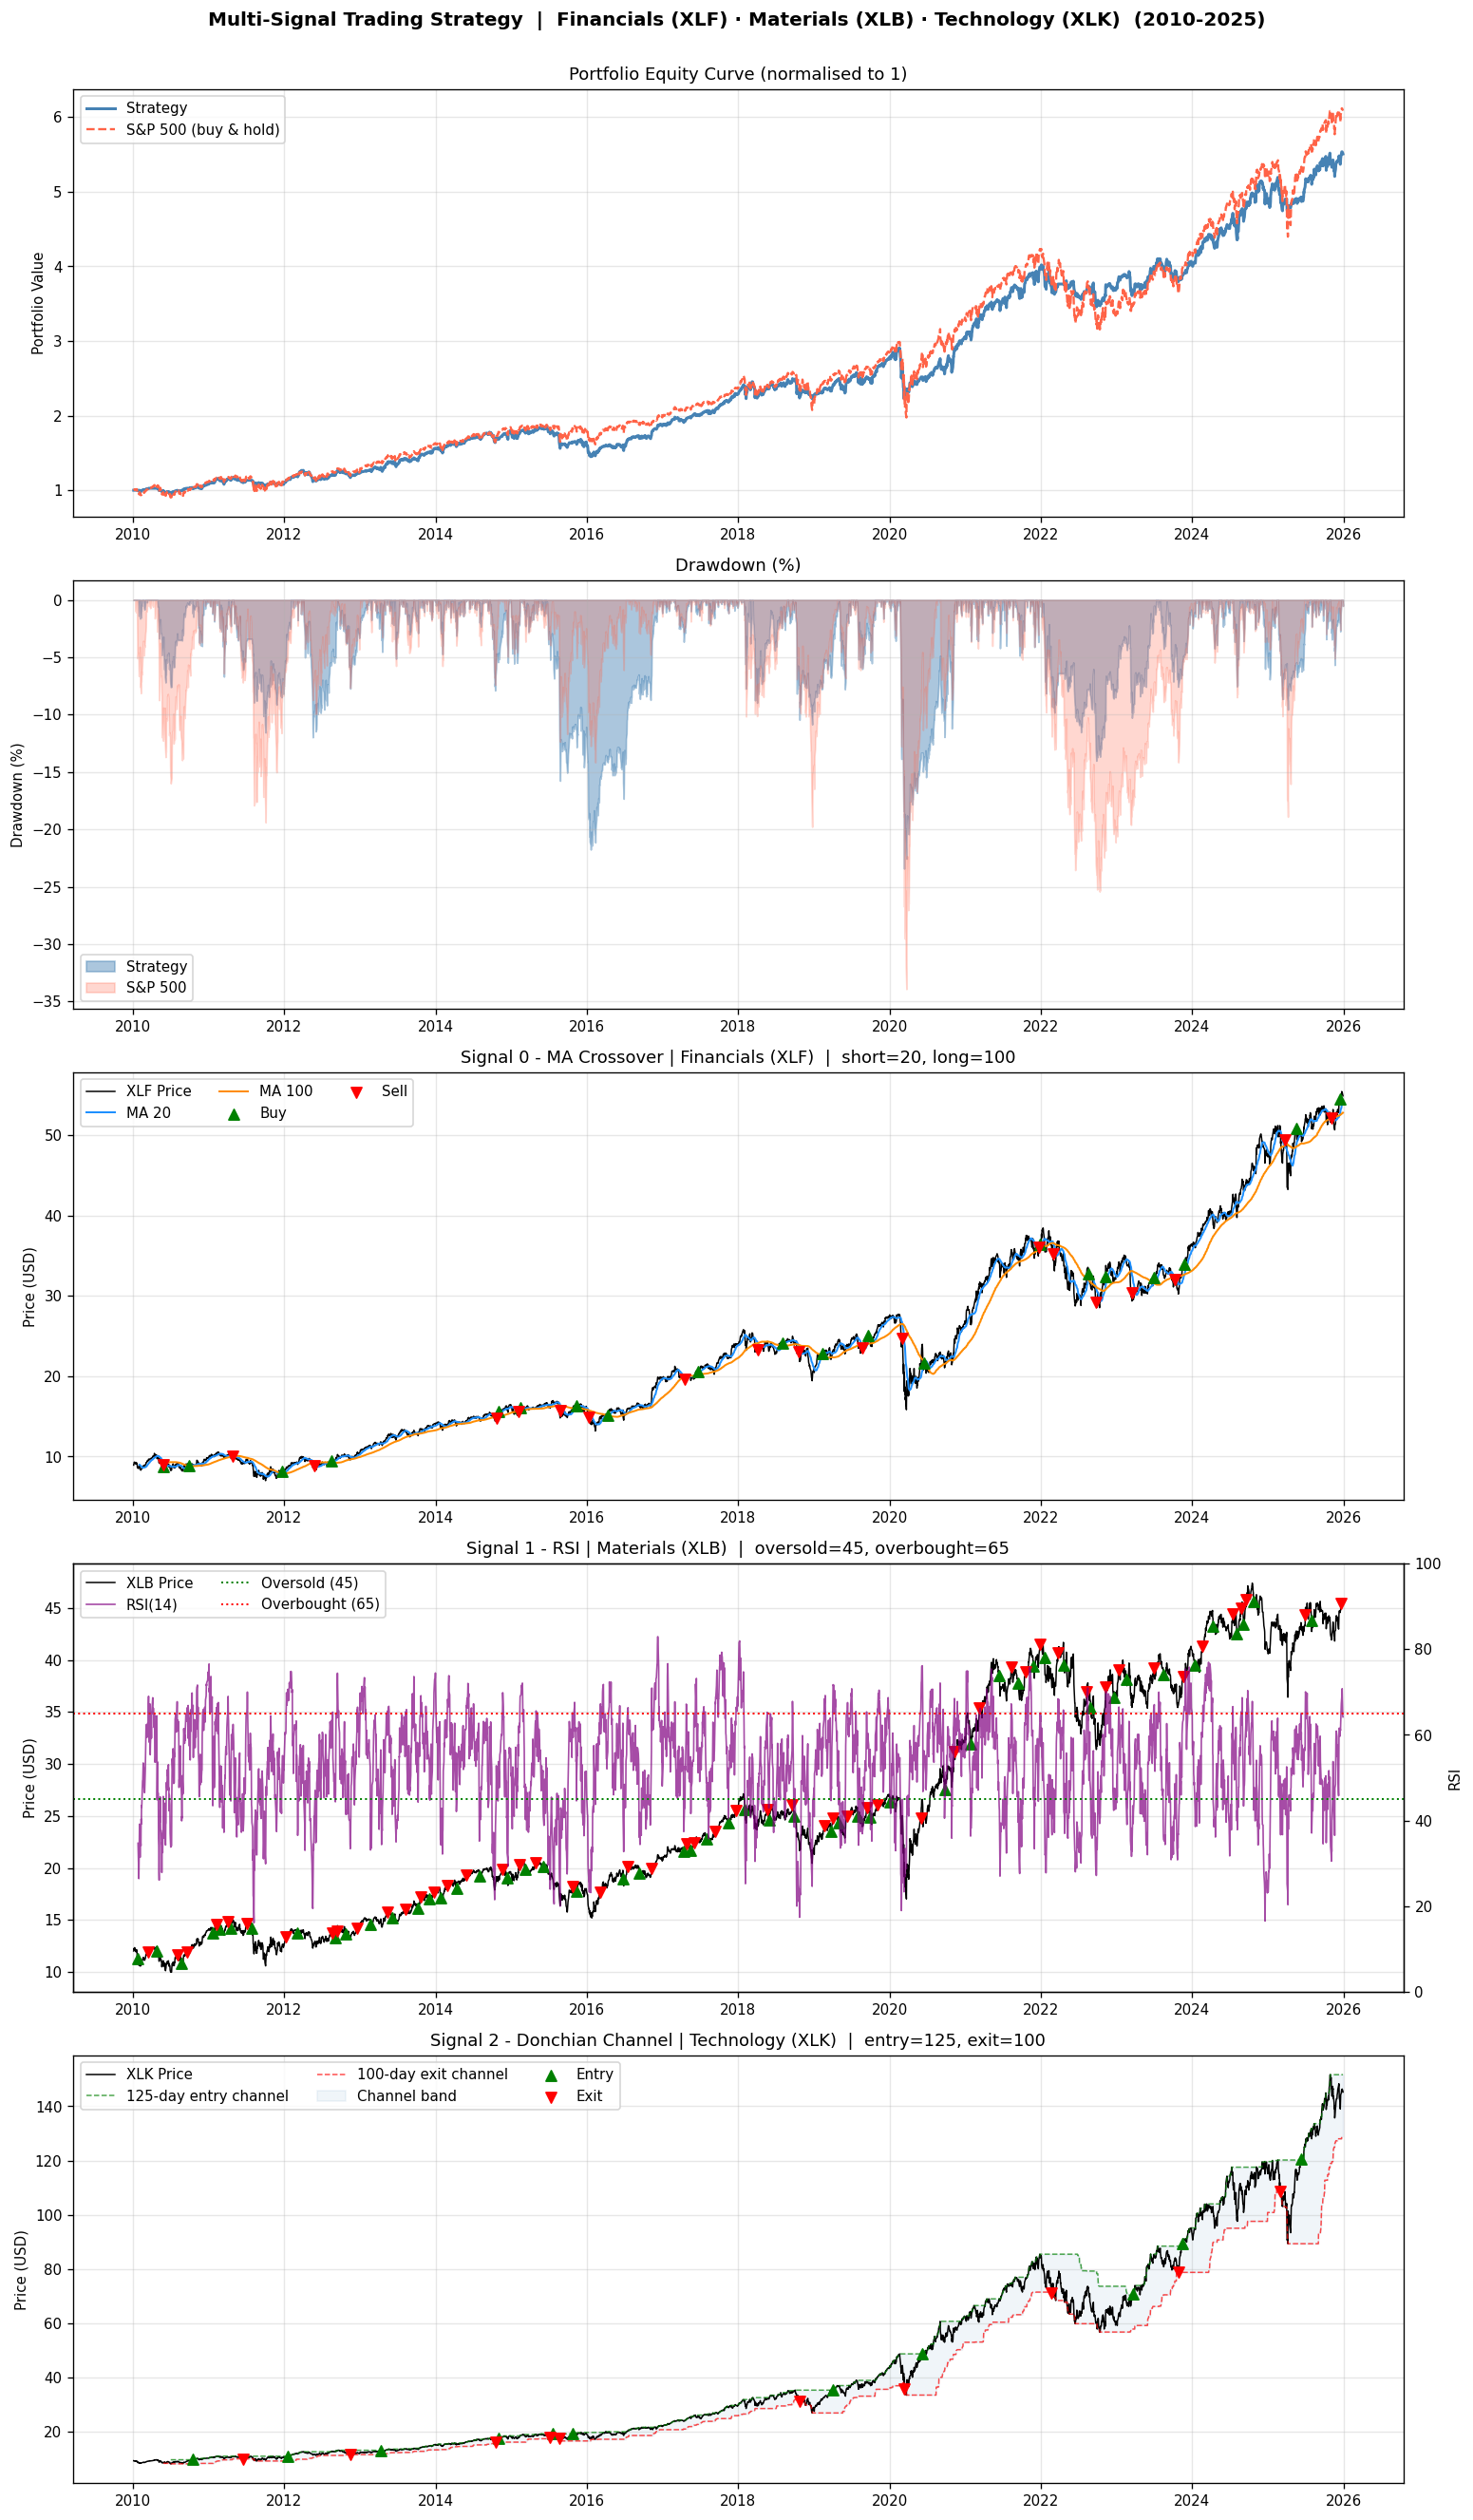

In [7]:
plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})
dates = df_prices.index

fig, axes = plt.subplots(5, 1, figsize=(13, 22))
fig.suptitle('Multi-Signal Trading Strategy  |  Financials (XLF) · Materials (XLB) · Technology (XLK)  (2010-2025)',
             fontsize=12, fontweight='bold', y=1.002)

# 1. Equity Curve
ax = axes[0]
ax.plot(dates, portfolio_values, label='Strategy', color='steelblue', lw=1.8)
ax.plot(dates, spx_values,       label='S&P 500 (buy & hold)', color='tomato',
        lw=1.4, linestyle='--')
ax.set_title('Portfolio Equity Curve (normalised to 1)')
ax.set_ylabel('Portfolio Value')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.3)

# 2. Drawdown
ax = axes[1]
dd_strat = module.compute_drawdown_series(portfolio_values)
dd_spx   = module.compute_drawdown_series(spx_values)
ax.fill_between(dates, dd_strat * 100, 0, color='steelblue', alpha=0.45, label='Strategy')
ax.fill_between(dates, dd_spx   * 100, 0, color='tomato',    alpha=0.25, label='S&P 500')
ax.set_title('Drawdown (%)')
ax.set_ylabel('Drawdown (%)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.3)

# 3. Signal 0: MA Crossover - XLF
ax = axes[2]
rep0 = FINANCE_TICKERS[0]
sig0 = signals[rep0]
ax.plot(dates, df_prices[rep0], label=f'{rep0} Price', color='black', lw=0.9)
ax.plot(dates, sig0['short_ma'], label=f'MA {best_ma["short_window"]}',
        color='dodgerblue', lw=1.2)
ax.plot(dates, sig0['long_ma'],  label=f'MA {best_ma["long_window"]}',
        color='darkorange', lw=1.2)
buy_mask  = sig0['position_change'] > 0
sell_mask = sig0['position_change'] < 0
ax.scatter(dates[buy_mask],  df_prices[rep0][buy_mask],  marker='^', color='green', zorder=5, s=45, label='Buy')
ax.scatter(dates[sell_mask], df_prices[rep0][sell_mask], marker='v', color='red',   zorder=5, s=45, label='Sell')
ax.set_title(f'Signal 0 - MA Crossover | Financials (XLF)  |  '
             f'short={best_ma["short_window"]}, long={best_ma["long_window"]}')
ax.set_ylabel('Price (USD)')
ax.legend(ncol=3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.3)

# 4. Signal 1: RSI - XLB
ax4a = axes[3]
ax4b = ax4a.twinx()
rep1 = MATERIALS_TICKERS[0]
sig1 = signals[rep1]
ax4a.plot(dates, df_prices[rep1], color='black', lw=0.9, label=f'{rep1} Price')
buy_mask  = sig1['position_change'] > 0
sell_mask = sig1['position_change'] < 0
ax4a.scatter(dates[buy_mask],  df_prices[rep1][buy_mask],  marker='^', color='green', zorder=5, s=45)
ax4a.scatter(dates[sell_mask], df_prices[rep1][sell_mask], marker='v', color='red',   zorder=5, s=45)
ax4b.plot(dates, sig1['rsi'], color='purple', lw=1.0, alpha=0.7, label='RSI(14)')
ax4b.axhline(best_rsi['oversold'],   color='green', linestyle=':', lw=1.2, label=f'Oversold ({best_rsi["oversold"]})')
ax4b.axhline(best_rsi['overbought'], color='red',   linestyle=':', lw=1.2, label=f'Overbought ({best_rsi["overbought"]})')
ax4b.set_ylim(0, 100)
ax4b.set_ylabel('RSI')
ax4a.set_title(f'Signal 1 - RSI | Materials (XLB)  |  '
               f'oversold={best_rsi["oversold"]}, overbought={best_rsi["overbought"]}')
ax4a.set_ylabel('Price (USD)')
lines1, labels1 = ax4a.get_legend_handles_labels()
lines2, labels2 = ax4b.get_legend_handles_labels()
ax4a.legend(lines1 + lines2, labels1 + labels2, ncol=2)
ax4a.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax4a.grid(alpha=0.3)

# 5. Signal 2: Donchian Channel - XLK
ax5 = axes[4]
rep2 = TECHNOLOGY_TICKERS[0]
sig2 = signals[rep2]
ew2     = best_donchian['entry_window']
xw2     = best_donchian['exit_window']
ch_high = sig2['entry_high'].to_numpy()
ch_low  = sig2['exit_low'].to_numpy()
ax5.plot(dates, df_prices[rep2], color='black', lw=0.9, label=f'{rep2} Price')
ax5.plot(dates, ch_high, color='green', lw=0.9, linestyle='--', alpha=0.7, label=f'{ew2}-day entry channel')
ax5.plot(dates, ch_low,  color='red',   lw=0.9, linestyle='--', alpha=0.7, label=f'{xw2}-day exit channel')
ax5.fill_between(dates, ch_high, ch_low, alpha=0.08, color='steelblue', label='Channel band')
buy_mask  = sig2['position_change'] > 0
sell_mask = sig2['position_change'] < 0
ax5.scatter(dates[buy_mask],  df_prices[rep2][buy_mask],  marker='^', color='green', zorder=5, s=45, label='Entry')
ax5.scatter(dates[sell_mask], df_prices[rep2][sell_mask], marker='v', color='red',   zorder=5, s=45, label='Exit')
ax5.set_title(f'Signal 2 - Donchian Channel | Technology (XLK)  |  entry={ew2}, exit={xw2}')
ax5.set_ylabel('Price (USD)')
ax5.legend(ncol=3)
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax5.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. Robustness

### Parameter Sensitivity

The heatmaps show IS Sortino across the full parameter grid. A smooth plateau around the chosen parameters (★) confirms the signals are robust, not knife-edge fit.

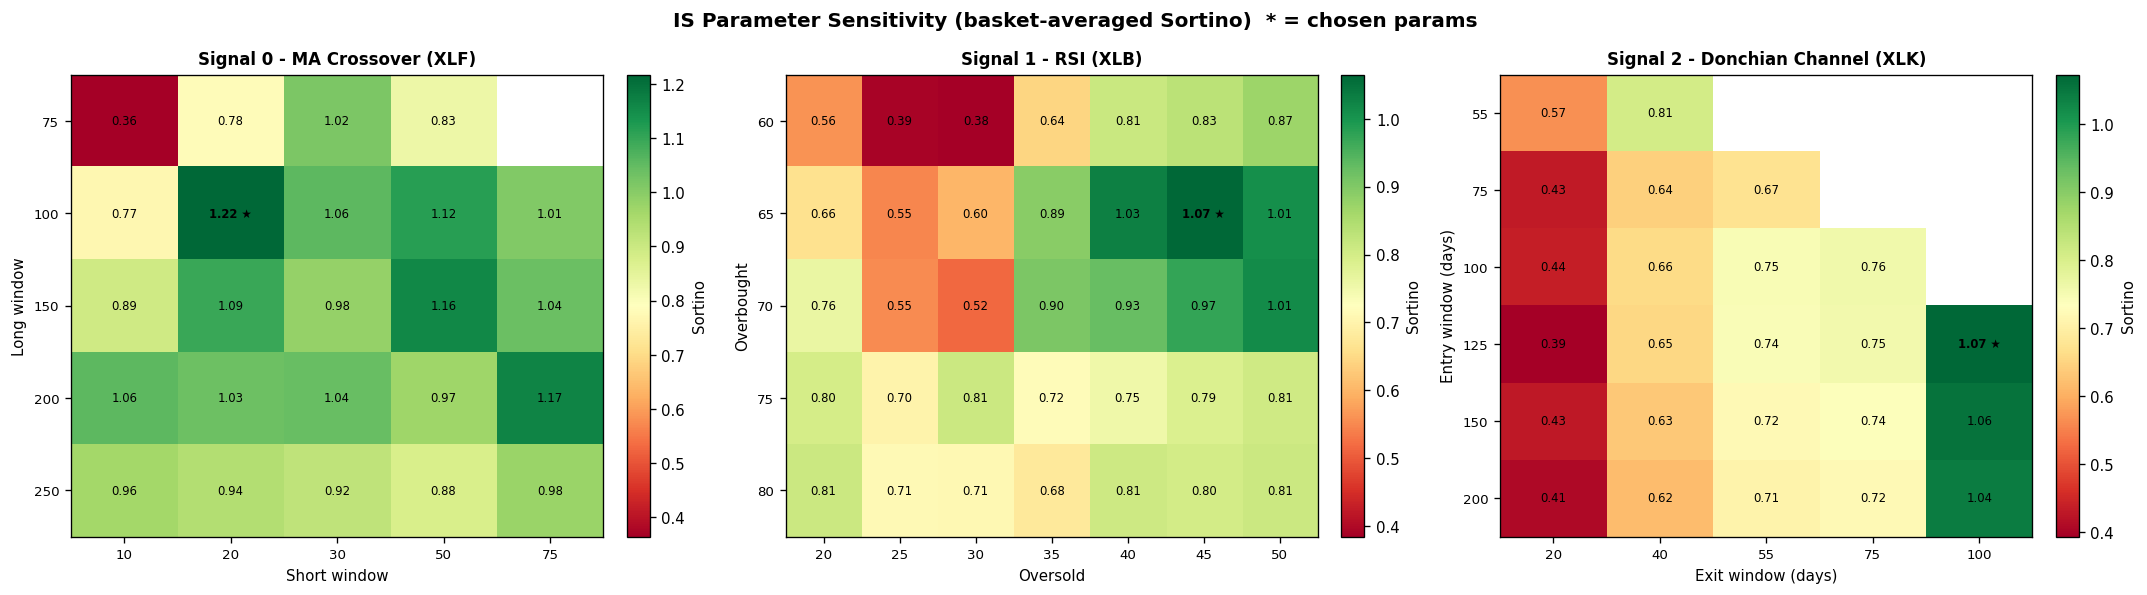

In [8]:
# IS sensitivity sweep - basket-averaged Sortino across the full parameter grid

short_windows = [10, 20, 30, 50, 75]
long_windows  = [75, 100, 150, 200, 250]
ma_sharpe = np.full((len(long_windows), len(short_windows)), np.nan)
for li, lw in enumerate(long_windows):
    for si, sw in enumerate(short_windows):
        if sw >= lw: continue
        ma_sharpe[li, si] = module.basket_sortino(module.ma_signal,
                                                   df_prices[FINANCE_TICKERS][is_mask],
                                                   short_window=sw, long_window=lw)

oversold_levels   = [20, 25, 30, 35, 40, 45, 50]
overbought_levels = [60, 65, 70, 75, 80]
rsi_sharpe = np.full((len(overbought_levels), len(oversold_levels)), np.nan)
for oi, ob in enumerate(overbought_levels):
    for si, os_ in enumerate(oversold_levels):
        if os_ >= ob: continue
        rsi_sharpe[oi, si] = module.basket_sortino(module.rsi_signal,
                                                    df_prices[MATERIALS_TICKERS][is_mask],
                                                    period=14, oversold=os_, overbought=ob)

don_ew_vals = [55, 75, 100, 125, 150, 200]
don_xw_vals = [20, 40, 55, 75, 100]
donchian_mat = np.full((len(don_ew_vals), len(don_xw_vals)), np.nan)
for ei, ew in enumerate(don_ew_vals):
    for xi, xw in enumerate(don_xw_vals):
        if xw >= ew:
            continue
        donchian_mat[ei, xi] = module.basket_sortino(module.donchian_signal,
                                                      df_prices[TECHNOLOGY_TICKERS][is_mask],
                                                      entry_window=ew, exit_window=xw)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('IS Parameter Sensitivity (basket-averaged Sortino)  * = chosen params',
             fontsize=12, fontweight='bold')

module.draw_heatmap(axes[0], ma_sharpe,
             [str(l) for l in long_windows], [str(s) for s in short_windows],
             'Long window', 'Short window',
             'Signal 0 - MA Crossover (XLF)',
             star_row=long_windows.index(best_ma['long_window']),
             star_col=short_windows.index(best_ma['short_window']))

module.draw_heatmap(axes[1], rsi_sharpe,
             [str(o) for o in overbought_levels], [str(o) for o in oversold_levels],
             'Overbought', 'Oversold',
             'Signal 1 - RSI (XLB)',
             star_row=overbought_levels.index(best_rsi['overbought']),
             star_col=oversold_levels.index(best_rsi['oversold']))

module.draw_heatmap(axes[2], donchian_mat,
             [str(ew) for ew in don_ew_vals],
             [str(xw) for xw in don_xw_vals],
             'Entry window (days)', 'Exit window (days)',
             'Signal 2 - Donchian Channel (XLK)',
             star_row=don_ew_vals.index(best_donchian['entry_window']),
             star_col=don_xw_vals.index(best_donchian['exit_window']))

plt.tight_layout()
plt.show()

### Deflated Sharpe Ratio

We correct for multiple-testing inflation, the DSR adjusts IS Sharpe for the number of parameter combinations we tested. A DSR above 95% indicates genuine skill rather than overfitting.

In [9]:
# Deflated Sharpe Ratio (Bailey & Lopez de Prado 2014) - corrects for multiple-testing
# inflation when the best Sharpe is selected from n_trials parameter combinations.

is_mask = df_prices.index <= '2019-12-31'
n_is    = int(np.sum(is_mask))

def is_returns(ticker, sig_df):
    px  = df_prices[ticker][is_mask].to_numpy()
    pr  = np.concatenate(([0.0], px[1:] / px[:-1] - 1))
    sig = sig_df['signal'][is_mask].to_numpy()
    return (pr[1:] * sig[:-1])   # signal[t-1] * return[t]

r_ma_is       = is_returns(FINANCE_TICKERS[0],    signals[FINANCE_TICKERS[0]])
r_rsi_is      = is_returns(MATERIALS_TICKERS[0],  signals[MATERIALS_TICKERS[0]])
r_donchian_is = is_returns(TECHNOLOGY_TICKERS[0], signals[TECHNOLOGY_TICKERS[0]])

n_t_ma       = int(np.sum(~np.isnan(ma_sharpe)))
n_t_rsi      = int(np.sum(~np.isnan(rsi_sharpe)))
n_t_donchian = int(np.sum(~np.isnan(donchian_mat)))

rows = [
    ('MA  (Finance)',      r_ma_is,       n_t_ma,       'short/long window'),
    ('RSI (Materials)',    r_rsi_is,      n_t_rsi,      'oversold/overbought'),
    ('Donchian (Tech.)',   r_donchian_is, n_t_donchian, 'entry/exit window'),
]

print('=' * 72)
print('  Deflated Sharpe Ratio  |  Bailey & Lopez de Prado (2014)')
print(f'  IS period: 2010-2019  ({n_is} days)   correction for multiple testing')
print('=' * 72)
print(f'  {"Signal":<18} {"SR (IS)":>7} {"n_trials":>9} {"SR*":>7} {"DSR":>8}  {"Verdict"}')
print('-' * 72)
for label, r_is, n_t, params_desc in rows:
    sr_is        = module.compute_sharpe(r_is)
    skew, kurt   = module.numpy_moments(r_is)
    dsr, sr_star = module.compute_deflated_sharpe(
        sr_is, n_trials=n_t, n_observations=n_is,
        skewness=skew, kurtosis=kurt
    )
    verdict = ('Genuine skill' if dsr > 0.95
               else ('Borderline'   if dsr > 0.80
               else  'Likely luck'))
    print(f'  {label:<18} {sr_is:>7.3f} {n_t:>9d} {sr_star:>7.3f} {dsr:>8.3%}  {verdict}')
print('=' * 72)
print()
print('SR*  = expected max Sharpe across n_trials random strategies.')
print('DSR  = P(observed SR > SR* | null: performance is due to luck alone).')

  Deflated Sharpe Ratio  |  Bailey & Lopez de Prado (2014)
  IS period: 2010-2019  (2516 days)   correction for multiple testing
  Signal             SR (IS)  n_trials     SR*      DSR  Verdict
------------------------------------------------------------------------
  MA  (Finance)        0.845        24   0.061 100.000%  Genuine skill
  RSI (Materials)      0.745        35   0.065 100.000%  Genuine skill
  Donchian (Tech.)     0.773        24   0.061 100.000%  Genuine skill

SR*  = expected max Sharpe across n_trials random strategies.
DSR  = P(observed SR > SR* | null: performance is due to luck alone).


---
## 5. Walk-Forward Validation

We fix parameters on IS data and evaluate once on held-out OOS data.

| Period | Dates | Role |
|--------|-------|------|
| $\mathcal{D}_{IS}$ | 2010-2019 | Parameter optimisation |
| $\mathcal{D}_{OOS1}$ | 2020-2025 | Held-out evaluation |
| $\mathcal{D}_{OOS2}$ | 2000-2009 | Pre-sample stress test |


In [10]:
train_end  = '2019-12-31'
test_start = '2020-01-01'
oos2_start = '2000-01-01'
oos2_end   = '2009-12-31'


def period_stats(label, df_p, df_pc):
    tks_traded = FINANCE_TICKERS + MATERIALS_TICKERS + TECHNOLOGY_TICKERS
    sigs = {}
    for t in FINANCE_TICKERS:    sigs[t] = signal_0(df_p[t])
    for t in MATERIALS_TICKERS:  sigs[t] = signal_1(df_p[t])
    for t in TECHNOLOGY_TICKERS: sigs[t] = signal_2(df_p[t])

    pos_chg = pd.concat([sigs[t]['position_change'].rename(t) for t in tks_traded], axis=1)
    df_pos  = module.run_portfolio(df_p[tks_traded], df_pc, pos_chg)
    pv      = df_pos.to_numpy().sum(axis=1)
    dr      = pv[1:] / pv[:-1] - 1
    spx_p   = df_p['^GSPC'].to_numpy()
    spx_v   = spx_p / spx_p[0]
    spx_r   = spx_p[1:] / spx_p[:-1] - 1

    print(f'  {label}')
    print(f'  {"CAGR":<18} {module.compute_cagr(pv):>8.1%}   S&P: {module.compute_cagr(spx_v):.1%}')
    print(f'  {"Sharpe":<18} {module.compute_sharpe(dr):>8.2f}   S&P: {module.compute_sharpe(spx_r):.2f}')
    print(f'  {"Sortino":<18} {module.compute_sortino(dr):>8.2f}')
    print(f'  {"Calmar":<18} {module.compute_calmar(pv):>8.2f}')
    print(f'  {"Ann. Volatility":<18} {module.compute_annual_volatility(dr):>8.1%}')
    print(f'  {"Max Drawdown":<18} {module.compute_max_drawdown(pv):>8.1%}   S&P: {module.compute_max_drawdown(spx_v):.1%}')
    print()


# Load extended price data (2000-2025) for OOS2 without touching df_prices (2010-2025)
_fin_ext  = pd.read_csv(data_dir / 'xlf_ext.csv',         index_col=0, parse_dates=True)[FINANCE_TICKERS]
_mats_ext = pd.read_csv(data_dir / 'sector_etfs_ext.csv', index_col=0, parse_dates=True)[MATERIALS_TICKERS]
_tech_ext = pd.read_csv(data_dir / 'sector_etfs_ext.csv', index_col=0, parse_dates=True)[TECHNOLOGY_TICKERS]
_spx_ext  = pd.read_csv(data_dir / 'spx_ext.csv',         index_col=0, parse_dates=True)[['^GSPC']]
df_prices_ext = (_fin_ext.join(_mats_ext, how='outer')
                          .join(_tech_ext, how='outer')
                          .join(_spx_ext,  how='outer')
                          .ffill().dropna())
df_prices_ext.index = pd.to_datetime(df_prices_ext.index)

oos2_mask  = (df_prices_ext.index >= oos2_start) & (df_prices_ext.index <= oos2_end)
df_oos2    = df_prices_ext[oos2_mask]
df_pc_oos2 = module.make_price_changes(df_oos2)


print('=' * 48)
print('  Walk-Forward Validation')
print('=' * 48)
train_mask = df_prices.index <= train_end
period_stats('IN-SAMPLE   (2010-2019)',
             df_prices[train_mask],
             df_price_changes[train_mask])

test_mask = df_prices.index >= test_start
period_stats('OOS1  OUT-OF-SAMPLE (2020-2025)',
             df_prices[test_mask],
             df_price_changes[test_mask])

period_stats('OOS2  PRE-SAMPLE STRESS (2000-2009)',
             df_oos2,
             df_pc_oos2)
print('=' * 48)

  Walk-Forward Validation
  IN-SAMPLE   (2010-2019)
  CAGR                  10.7%   S&P: 11.1%
  Sharpe                 0.95   S&P: 0.79
  Sortino                1.33
  Calmar                 0.49
  Ann. Volatility       11.3%
  Max Drawdown         -21.8%   S&P: -19.8%

  OOS1  OUT-OF-SAMPLE (2020-2025)
  CAGR                  13.6%   S&P: 13.4%
  Sharpe                 1.09   S&P: 0.70
  Sortino                1.59
  Calmar                 0.98
  Ann. Volatility       12.4%
  Max Drawdown         -13.9%   S&P: -33.9%

  OOS2  PRE-SAMPLE STRESS (2000-2009)
  CAGR                   5.3%   S&P: -2.6%
  Sharpe                 0.50   S&P: -0.01
  Sortino                0.73
  Calmar                 0.24
  Ann. Volatility       11.5%
  Max Drawdown         -21.5%   S&P: -56.8%



---

**References:**
- Bailey, D. H., & Lopez de Prado, M. (2014). *The Deflated Sharpe Ratio.* JPM, 40(5), 94–107.
- De Bondt, W., & Thaler, R. (1985). *Does the Stock Market Overreact?* JF, 40(3), 793–805.
- McLean, R. D., & Pontiff, J. (2016). *Does Publishing Research Destroy Stock Return Predictability?* JF, 71(1), 5–32.
- Shleifer, A., & Vishny, R. (1997). *The Limits of Arbitrage.* JF, 52(1), 35–55.